Probabilidade de estar em terra no Natal: 76.98%


/home/akel/anaconda2025/lib/python3.13/site-packages/matplotlib/axes/_axes.py:7093: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  m, bins = np.histogram(x[i], bins, weights=w[i], **hist_kwargs)


TypeError: numpy boolean subtract, the `-` operator, is not supported, use the bitwise_xor, the `^` operator, or the logical_xor function instead.

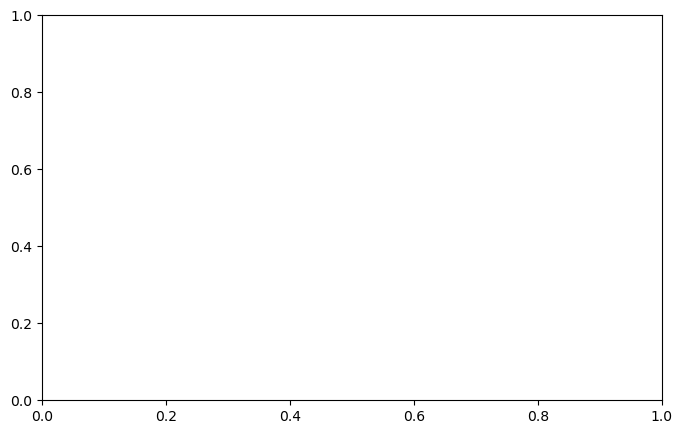

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from itertools import product

def simulacao_exaustiva(data_inicio, data_interesse, tempo_embarcado, tempo_folga,
                        embarque_adianta, embarque_atraso, folga_max_extra):
    """
    Simula todas as combinações possíveis de variações de embarque e folga
    e retorna as datas de estado (terra/mar) e o número de casos em terra.
    """
    data_atual = data_inicio
    dias_total = (data_interesse - data_inicio).days
    resultados = []

    variacoes_embarque = range(-embarque_adianta, embarque_atraso + 1)
    variacoes_folga = range(0, folga_max_extra + 1)

    for comb_embarque in product(variacoes_embarque, repeat=(dias_total // (tempo_embarcado + tempo_folga) + 2)):
        data = data_inicio
        em_terra = True
        for i, var_emb in enumerate(comb_embarque):
            if em_terra:
                duracao = tempo_folga + np.random.randint(0, folga_max_extra + 1)
            else:
                duracao = tempo_embarcado + var_emb
            data += timedelta(days=duracao)
            em_terra = not em_terra
            if data > data_interesse:
                break
        resultados.append((data, em_terra))

    return resultados

# --- Parâmetros do exemplo ---
data_inicio    = datetime(2025, 7, 1)
data_interesse = datetime(2025, 12, 25)
tempo_embarcado = 28
tempo_folga     = 28
embarque_adianta = 5
embarque_atraso = 10
folga_max_extra = 5

# --- Simulação ---
np.random.seed(42)
resultados = []
n_sim = 20000  # número de simulações aleatórias
for _ in range(n_sim):
    data = data_inicio
    em_terra = True
    while data < data_interesse:
        if em_terra:
            duracao = tempo_folga + np.random.randint(0, folga_max_extra + 1)
        else:
            duracao = tempo_embarcado + np.random.randint(-embarque_adianta, embarque_atraso + 1)
        data += timedelta(days=duracao)
        em_terra = not em_terra
    resultados.append(em_terra)

# --- Probabilidade ---
prob_terra = np.mean(resultados)
print(f"Probabilidade de estar em terra no Natal: {prob_terra:.2%}")

# --- Gráfico ---
plt.figure(figsize=(8,5))
plt.hist(resultados, bins=2, rwidth=0.6, color='skyblue', edgecolor='black')
plt.xticks([0,1], ['No mar', 'Em terra'])
plt.title('Distribuição de probabilidade — Natal 2025')
plt.ylabel('Frequência')
plt.grid(axis='y', alpha=0.3)
plt.show()


In [2]:
a=1.0e5

In [3]:
a

100000.0